**Датасет:** Avocado Prices  
**Источник:** [Kaggle - Avocado Prices](https://www.kaggle.com/datasets/neuromusic/avocado-prices)  
**Почему выбран:**  
1.  **Соответствие техническому заданию:** Содержит **18 249** записей и **14** колонок.
2.  **Четкая ML-задача:** Целевая переменная `AveragePrice` задает классическую задачу регрессии.

Импортируем все необходимые библиотеки

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

RANDOM_STATE = 42

Загрузим данные авкодадо

In [87]:

df = pd.read_csv('../data/raw/avocado.csv')

Датасет содержит информацию о еженедельных розничных продажах авокадо Hass в различных регионах США за период с 2015 по 2018 год. Данные собраны Hass Avocado Board и опубликованы на Kaggle.

### Базовая информация о датасете

Выведем базовую информацию

In [88]:
print("Размер датасета:", df.shape)

df.info()

Размер датасета: (18249, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [89]:
df.columns

Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')

**Структура датасета:**
- `Date` — дата наблюдения
- `AveragePrice` — **целевая переменная** (средняя цена одного авокадо в долларах)
- `Total Volume`, `4046`, `4225`, `4770` — объёмы продаж авокадо разных размеров (PLU-коды)
- `Total Bags`, `Small Bags`, `Large Bags`, `XLarge Bags` — продажи в пакетах
- `type` — тип авокадо (`conventional` / `organic`)
- `year`, `region` — год и регион продаж

In [90]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [91]:
df.tail()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico
18248,11,2018-01-07,1.62,17489.58,2894.77,2356.13,224.53,12014.15,11988.14,26.01,0.0,organic,2018,WestTexNewMexico


In [92]:
# Статическое опсиание
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


Средняя цена авокадо ≈ 1.41 $     
Цена варьируется от 0.44 $ до 3.25 $     
Объём продаж сильно скошен (много маленьких значений и несколько очень больших)    


Проверим пропуски и дубли


In [93]:
print("Пропуски:\n", df.isnull().sum())
print("Дубликаты:", df.duplicated().sum())

Пропуски:
 Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64
Дубликаты: 0


Как мы видим выше, никаких пропусков или дубликатов в датасете не наблюдается

### Очистка и подготовка данных

Удалим техническую колонку Unnamed

In [94]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [95]:

df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Преобразуем колонку Date в формат datetime

In [96]:
df['Date']=pd.to_datetime(df['Date'])

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


In [98]:
df['region'].nunique()

54

   
`region` содержит 54 уникальных признака. Создадим для них группы

In [99]:
# Группировка регионов 
def get_region_group(region):
    if region in ['California', 'LosAngeles', 'SanDiego', 'Sacramento']:
        return 'California'
    elif region in ['NewYork', 'Boston', 'Philadelphia', 'BaltimoreWashington']:
        return 'Northeast'
    elif region in ['Chicago', 'Detroit', 'GrandRapids']:
        return 'Midwest'
    elif region in ['Houston', 'DallasFtWorth', 'SouthCentral']:
        return 'South'
    elif region in ['Denver', 'LasVegas', 'PhoenixTucson', 'West']:
        return 'West'
    else:
        return 'Other'

df['region_group'] = df['region'].apply(get_region_group)


In [100]:
# One-Hot Encoding для группы регионов
df = pd.get_dummies(df, columns=['region_group'], drop_first=True)

Удалим ненужный столбец теперь

In [101]:
df.drop('region', axis=1, inplace=True)

Далее рассмотрим типы

In [102]:
df['type'].nunique()

2

`type` — категориальный признак с 2 значениями (conventional, organic), необходимо кодировать с помощью One-Hot Encoding.  

In [103]:
# One-Hot Encoding для типа авокадо
df = pd.get_dummies(df, columns=['type'], drop_first=True)

#### Добавим новые признаки

Новые временные признаки

In [104]:
df['dayofweek'] = df['Date'].dt.dayofweek
df['quarter'] = df['Date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

На всякий случае лагорифмируем объемные признаки (Они немного скошены)

In [105]:
volume_cols = ['Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
for col in volume_cols:
    df[f'log_{col}'] = np.log1p(df[col])

In [106]:
df['small_ratio'] = df['Small Bags'] / (df['Total Bags'] + 1)
df['large_ratio'] = df['Large Bags'] / (df['Total Bags'] + 1)
df['plu4046_ratio'] = df['4046'] / (df['Total Volume'] + 1)
df['organic_ratio'] = df['type_organic']

Убедимся, что признаки добавились и изменились

In [108]:
df.shape

(18249, 32)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18249 non-null  datetime64[ns]
 1   AveragePrice            18249 non-null  float64       
 2   Total Volume            18249 non-null  float64       
 3   4046                    18249 non-null  float64       
 4   4225                    18249 non-null  float64       
 5   4770                    18249 non-null  float64       
 6   Total Bags              18249 non-null  float64       
 7   Small Bags              18249 non-null  float64       
 8   Large Bags              18249 non-null  float64       
 9   XLarge Bags             18249 non-null  float64       
 10  year                    18249 non-null  int64         
 11  region_group_Midwest    18249 non-null  bool          
 12  region_group_Northeast  18249 non-null  bool  

In [111]:
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,log_4225,log_4770,log_Total Bags,log_Small Bags,log_Large Bags,log_XLarge Bags,small_ratio,large_ratio,plu4046_ratio,organic_ratio
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,...,10.905146,3.895080,9.070833,9.060055,4.545951,0.0,0.989164,0.010721,0.016139,False
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,...,10.706381,4.083115,9.159737,9.149429,4.589955,0.0,0.989640,0.010255,0.012287,False
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,...,11.600485,4.879007,9.005325,8.992584,4.645736,0.0,0.987216,0.012661,0.006722,False
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,...,11.184108,4.298373,8.667708,8.644425,4.903495,0.0,0.976814,0.023014,0.014330,False
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,...,10.688288,4.340944,8.729874,8.697389,5.291746,0.0,0.967875,0.031963,0.018446,False


#### Визуализация и изучение данных

Посмотрим распределние целевой переменной `average price`

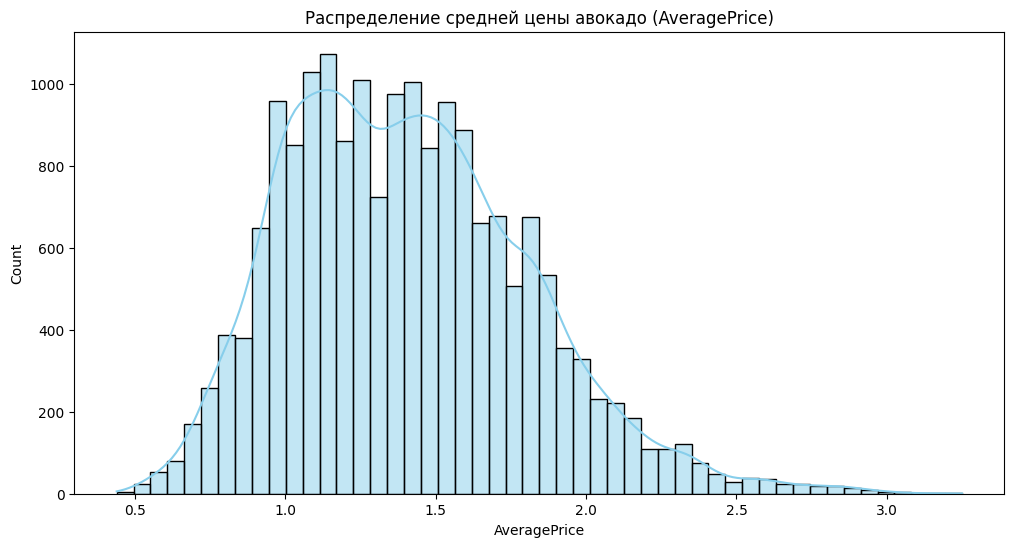

Средняя цена: 1.406
Медианная цена: 1.37
Skewness: 0.58


In [113]:
plt.figure(figsize=(12, 6))
sns.histplot(df['AveragePrice'], kde=True, bins=50, color='skyblue')
plt.title('Распределение средней цены авокадо (AveragePrice)')
plt.show()

print("Средняя цена:", df['AveragePrice'].mean().round(3))
print("Медианная цена:", df['AveragePrice'].median())
print("Skewness:", df['AveragePrice'].skew().round(3))

1) Получим распределние потребления разных видов авокадо

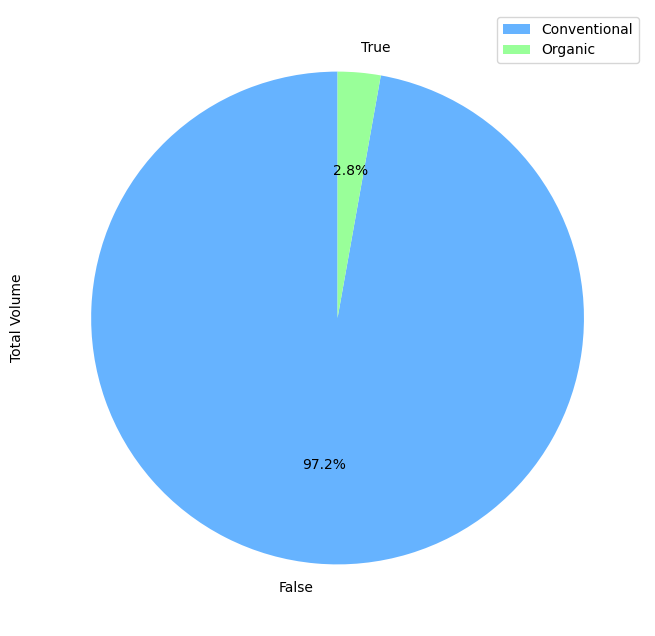

In [119]:
plt.figure(figsize=(8, 8))

type_volume = df.groupby('type_organic')['Total Volume'].sum()
labels = ['Conventional', 'Organic']

type_volume.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#99ff99'], startangle=90)
plt.legend(labels)
plt.show()


Как мы видим, только 2.8% составляют органические продукты. В то время как традиционные пользуются большим спросом

2) Посмотрим как распределяется цена 

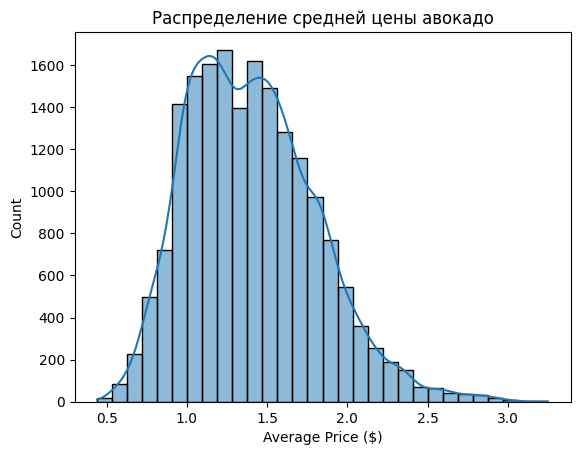

In [120]:
plt.figure()
sns.histplot(df['AveragePrice'], kde=True, bins=30)
plt.title('Распределение средней цены авокадо')
plt.xlabel('Average Price ($)')
plt.show()

В большинстве случаев цена авокадо находится в диапазоне от 1,1 до 1,4

2) Посмотрим распределение средней цены по типам авокадо

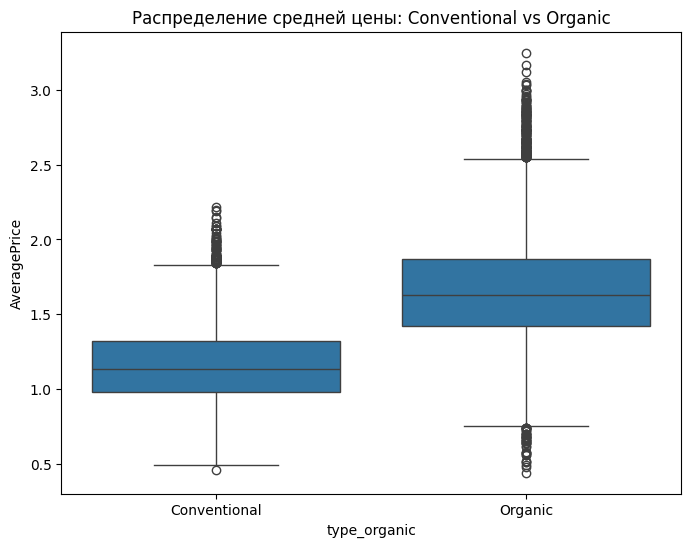

Средняя цена Conventional: 1.158
Средняя цена Organic:      1.654


In [124]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='type_organic', y='AveragePrice', data=df)
plt.title('Распределение средней цены: Conventional vs Organic')
plt.xticks([0, 1], ['Conventional', 'Organic'])
plt.show()

print("Средняя цена Conventional:", df[df['type_organic'] == 0]['AveragePrice'].mean().round(3))
print("Средняя цена Organic:     ", df[df['type_organic'] == 1]['AveragePrice'].mean().round(3))

3) смотрим распределение цены в зависимости от времени

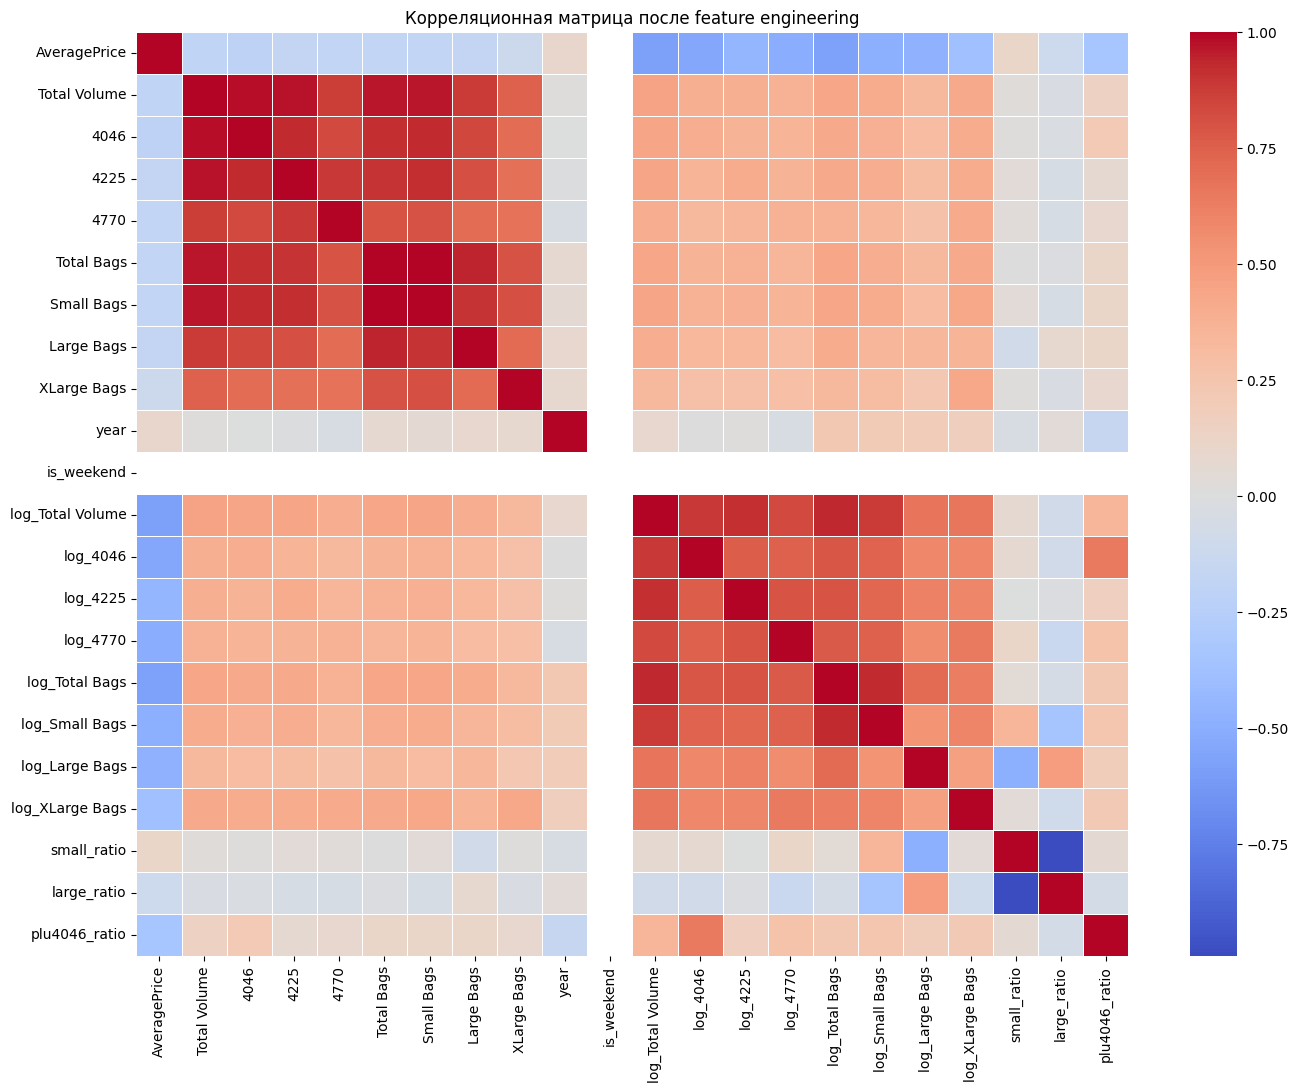

In [129]:
plt.figure(figsize=(16, 12))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Корреляционная матрица после feature engineering')
plt.show()

Посмотрим корреляцию признаков

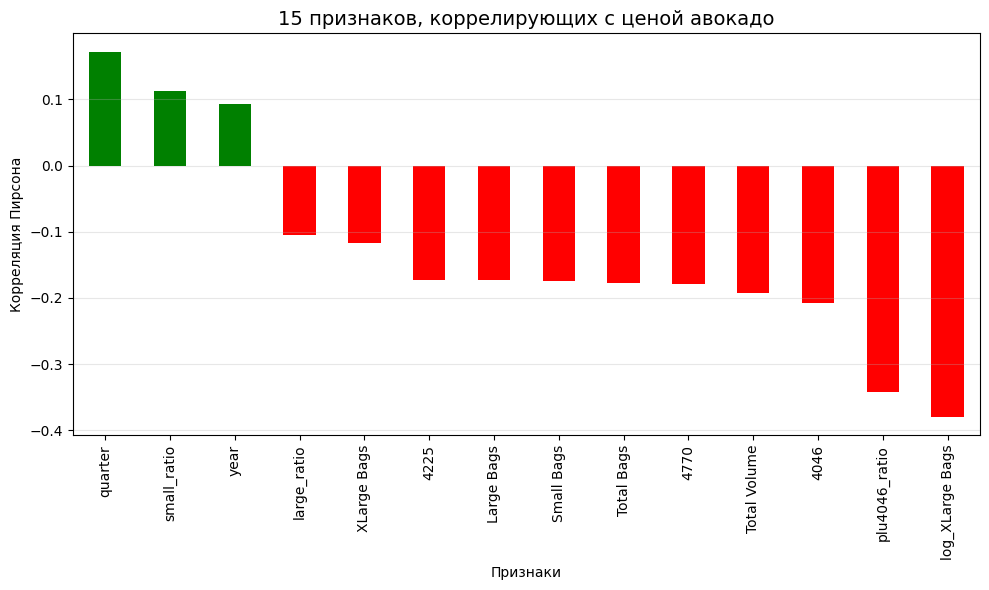

Топ-5 положительных корреляций:
quarter        0.172177
small_ratio    0.112163
year           0.093197
large_ratio   -0.105332
XLarge Bags   -0.117592
Name: AveragePrice, dtype: float64

Топ-5 отрицательных корреляций:
log_4046           -0.543861
log_Total Bags     -0.574931
log_Total Volume   -0.583411
dayofweek                NaN
is_weekend               NaN
Name: AveragePrice, dtype: float64


In [135]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_price = df[numeric_cols].corr()['AveragePrice'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in corr_with_price[1:15]]
corr_with_price[1:15].plot(kind='bar', color=colors)
plt.title('15 признаков, коррелирующих с ценой авокадо', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Корреляция Пирсона')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Топ-5 положительных корреляций:")
print(corr_with_price[1:6])
print("\nТоп-5 отрицательных корреляций:")
print(corr_with_price[-5:])

**Вывод**    

- `quarter` (0.17) — цена выше в 4-м квартале (осенью/зимой)

- `small_ratio` (0.11) — чем больше доля маленьких сумок, тем выше цена
- `year` (0.09) — цены постепенно растут с 2015 по 2018

- `log_Total Volume` (-0.58) — чем больше объем продаж, тем ниже цена (эффект масштаба)
- `log_Total Bags` (-0.57) — то же самое 
- `log_4046` (-0.54) — PLU-код 4046 (маленькие авокадо) имеет обратную связь с ценой

#### Поработаем над признаками для построения модели

Удалим столбец с датой, поскольку уже имеем год, дату и месяц

In [140]:
df_final=pd.get_dummies(df.drop(['Date'],axis=1),drop_first=True)

In [142]:
df_final.head()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,...,log_4225,log_4770,log_Total Bags,log_Small Bags,log_Large Bags,log_XLarge Bags,small_ratio,large_ratio,plu4046_ratio,organic_ratio
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,...,10.905146,3.895080,9.070833,9.060055,4.545951,0.0,0.989164,0.010721,0.016139,False
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,...,10.706381,4.083115,9.159737,9.149429,4.589955,0.0,0.989640,0.010255,0.012287,False
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,...,11.600485,4.879007,9.005325,8.992584,4.645736,0.0,0.987216,0.012661,0.006722,False
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,...,11.184108,4.298373,8.667708,8.644425,4.903495,0.0,0.976814,0.023014,0.014330,False
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,...,10.688288,4.340944,8.729874,8.697389,5.291746,0.0,0.967875,0.031963,0.018446,False


In [143]:
df_final.tail()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,...,log_4225,log_4770,log_Total Bags,log_Small Bags,log_Large Bags,log_XLarge Bags,small_ratio,large_ratio,plu4046_ratio,organic_ratio
18244,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,2018,...,7.333154,0.000000,9.510421,9.477908,6.070391,0.0,0.967936,0.031990,0.119875,True
18245,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,2018,...,8.141044,0.000000,9.134090,9.098407,5.786284,0.0,0.964839,0.035053,0.085801,True
18246,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,2018,...,7.805389,6.591591,9.147945,9.143431,3.768384,0.0,0.995390,0.004503,0.086573,True
18247,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,2018,...,8.000363,6.590315,9.302969,9.298401,3.931826,0.0,0.995351,0.004558,0.094262,True
18248,1.62,17489.58,2894.77,2356.13,224.53,12014.15,11988.14,26.01,0.0,2018,...,7.765200,5.418453,9.393924,9.391757,3.296207,0.0,0.997752,0.002165,0.165505,True


Выполним хронологический сплит данных

In [145]:
df_with_date = df_final.copy()
df_with_date['Date'] = pd.to_datetime(df['Date'])

Сортируем по дате

In [146]:
df_with_date = df_with_date.sort_values('Date')

Далее раздлеим так, все что до 2018 - train, 2018 - test

In [147]:
split_date = '2017-12-31'
train = df_with_date[df_with_date['Date'] <= split_date].copy()
test = df_with_date[df_with_date['Date'] > split_date].copy()

Удалим Date

In [148]:
train = train.drop('Date', axis=1)
test = test.drop('Date', axis=1)

Отделяем target

In [149]:
X_train = train.drop('AveragePrice', axis=1)
y_train = train['AveragePrice']
X_test = test.drop('AveragePrice', axis=1)
y_test = test['AveragePrice']

In [151]:
print(f"Train: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Test:  {X_test.shape[0]} строк, {X_test.shape[1]} признаков")
print(f"\nTrain период: {df[df['Date'] <= split_date]['Date'].min()} - {df[df['Date'] <= split_date]['Date'].max()}")
print(f"Test период:  {df[df['Date'] > split_date]['Date'].min()} - {df[df['Date'] > split_date]['Date'].max()}")

Train: 16953 строк, 30 признаков
Test:  1296 строк, 30 признаков

Train период: 2015-01-04 00:00:00 - 2017-12-31 00:00:00
Test период:  2018-01-07 00:00:00 - 2018-03-25 00:00:00


#### Метрики качества


 1. Основная метрика: **MAE**
 2. Дополнительная метрика: **R² (Коэффициент детерминации)**

MAE выбрана в качестве основной метрики, потому что она показывает результат в долларах и центах. В отличие от квадратичных ошибок, MAE не так сильно регаирует на выбросы.     
R² дополняет, показывает бщую эффективность модели относительно средних значений.


#### Моделирование / Baseline models

**Dummy**

In [154]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print(f"\n1. DUMMY (предсказание среднего):")
print(f"   MAE: {mae_dummy:.4f} USD")
print(f"   R²:  {r2_dummy:.4f}")


1. DUMMY (предсказание среднего):
   MAE: 0.2519 USD
   R²:  -0.0423


**Linear Regression**

In [157]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n2. LINEAR REGRESSION:")
print(f"   MAE: {mae_lr:.4f} USD")
print(f"   R²:  {r2_lr:.4f}")
print(f"   Linear Regression vs Dummy: {((mae_dummy - mae_lr)/mae_dummy)*100:.1f}%")



2. LINEAR REGRESSION:
   MAE: 0.2014 USD
   R²:  0.3311
   Linear Regression vs Dummy: 20.0%


**Random Forest**

In [158]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n3. RANDOM FOREST (n_estimators=100):")
print(f"   MAE: {mae_rf:.4f} USD")
print(f"   R²:  {r2_rf:.4f}")
print(f"   Random Forest vs Linear Regression: {((mae_lr - mae_rf)/mae_lr)*100:.1f}%")


3. RANDOM FOREST (n_estimators=100):
   MAE: 0.1722 USD
   R²:  0.4866
   Random Forest vs Linear Regression: 14.5%


#### Сравниталеьная таблица

In [159]:
results = pd.DataFrame({
    'Модель': ['Dummy (Mean)', 'Linear Regression', 'Random Forest'],
    'MAE (USD)': [f"{mae_dummy:.4f}", f"{mae_lr:.4f}", f"{mae_rf:.4f}"],
    'R²': [f"{r2_dummy:.4f}", f"{r2_lr:.4f}", f"{r2_rf:.4f}"],
    'Улучшение MAE': ['-', f"{(mae_dummy - mae_lr)/mae_dummy*100:.1f}%", 
                           f"{(mae_dummy - mae_rf)/mae_dummy*100:.1f}%"]
})

print(results.to_string(index=False))

           Модель MAE (USD)      R² Улучшение MAE
     Dummy (Mean)    0.2519 -0.0423             -
Linear Regression    0.2014  0.3311         20.0%
    Random Forest    0.1722  0.4866         31.6%


#### Вывод

Все обученные модели показали результат лучше, чем стратегия Dummy Mean. Мы видим, что даже простая линейная регрессия снижает ошибку на 20%, а это значит, что в данных есть четкие закономерности, которые алгоритмы успешно подхватывают.    

Random forest заметно лучше линейной регрессии. Это говорит о том, что зависимость цены от факторов нелинейная, и деревья решений справляются с ней гораздо лучше.   
